In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Root directory where your dataset lives in Drive
DATA_ROOT = "/content/drive/MyDrive/capture24"

# Paths
METADATA_CSV = os.path.join(DATA_ROOT, "metadata.csv")
SIGNAL_GLOB = os.path.join(DATA_ROOT, "**", "*.csv.gz")  # recursive search
OUTPUT_SUMMARY = os.path.join(DATA_ROOT, "inventory_integrity_summary.csv")

# (keep the rest of your code the same)


In [ ]:
import os, glob, gzip, re
import numpy as np
import pandas as pd


files = sorted([f for f in glob.glob(SIGNAL_GLOB, recursive=True) if os.path.isfile(f)])
print(f"Found {len(files)} csv.gz files; showing 5 examples:")
for f in files[:5]:
    print(" -", f)

if os.path.exists(METADATA_CSV):
    meta = pd.read_csv(METADATA_CSV)
    print("\nMetadata head:")
    display(meta.head())
else:
    meta = None
    print("\nWARNING: metadata.csv not found")

# Quick peek first file header lines
def quick_head(path, n=5):
    with gzip.open(path, "rt") as f:
        return [next(f) for _ in range(n)]

if files:
    print("\nFirst 5 lines of first csv.gz:")
    for line in quick_head(files[0], 5):
        print(line.strip())


Found 151 csv.gz files; showing 5 examples:
 - /content/drive/MyDrive/capture24/P001.csv.gz
 - /content/drive/MyDrive/capture24/P002.csv.gz
 - /content/drive/MyDrive/capture24/P003.csv.gz
 - /content/drive/MyDrive/capture24/P004.csv.gz
 - /content/drive/MyDrive/capture24/P005.csv.gz

Metadata head:


,pid,age,sex
0,P001,38-52,F
1,P002,30-37,F
2,P003,30-37,F
3,P004,53+,F
4,P005,38-52,F



First 5 lines of first csv.gz:
time,x,y,z,annotation
2016-11-13 02:18:00.000000,-0.46669036,-0.5333412,0.65847206,7030 sleeping;MET 0.95
2016-11-13 02:18:00.010000,-0.46669036,-0.5333412,0.65847206,7030 sleeping;MET 0.95
2016-11-13 02:18:00.020000,-0.46669036,-0.5333412,0.65847206,7030 sleeping;MET 0.95
2016-11-13 02:18:00.030000,-0.46669036,-0.5333412,0.65847206,7030 sleeping;MET 0.95


In [ ]:
def infer_time_col(df):
    for c in ["timestamp", "time", "datetime", "ts"]:
        if c in df.columns: return c
    return None

def infer_accel_cols(df):
    candidates = []
    axis = ["x","y","z"]
    prefixes = ["accel_", "acc_", ""]
    for ax in axis:
        found = None
        for p in prefixes:
            c = p+ax
            if c in df.columns:
                found = c; break
        candidates.append(found)
    if any(c is None for c in candidates): return None
    return candidates

def load_signal_df(path, nrows=None):
    df = pd.read_csv(path, compression="gzip", nrows=nrows)
    tcol = infer_time_col(df)
    acols = infer_accel_cols(df)
    return df, tcol, acols

test_path = files[0]
df, tcol, acols = load_signal_df(test_path, nrows=20000)
print("Inferred time col:", tcol, "| accel cols:", acols)
print("Shape:", df.shape, "| dtypes:")
print(df.dtypes.head(10))
print("NaN fraction (first 10k rows):", float(df.isna().mean().mean()))
display(df.head())


Inferred time col: time | accel cols: ['x', 'y', 'z']
Shape: (20000, 5) | dtypes:
time           object
x             float64
y             float64
z             float64
annotation     object
dtype: object
NaN fraction (first 10k rows): 0.0


,time,x,y,z,annotation
0,2016-11-13 02:18:00.000000,-0.46669,-0.533341,0.658472,7030 sleeping;MET 0.95
1,2016-11-13 02:18:00.010000,-0.46669,-0.533341,0.658472,7030 sleeping;MET 0.95
2,2016-11-13 02:18:00.020000,-0.46669,-0.533341,0.658472,7030 sleeping;MET 0.95
3,2016-11-13 02:18:00.030000,-0.46669,-0.533341,0.658472,7030 sleeping;MET 0.95
4,2016-11-13 02:18:00.040000,-0.46669,-0.533341,0.658472,7030 sleeping;MET 0.95


In [ ]:
def to_epoch_seconds(series):
    if np.issubdtype(series.dtype, np.number):
        return series.astype(float).values
    t = pd.to_datetime(series, utc=True, errors="coerce")
    return (t.astype("int64").values / 1e9)

def sampling_report(t_epoch, fs=100.0, tol=0.002):
    if len(t_epoch) < 3:
        return {"rows": len(t_epoch), "median_dt": np.nan, "gaps": 0, "dup_ts": 0, "max_gap_s": np.nan}
    dt = np.diff(t_epoch)
    period = 1.0/fs
    gaps = int(np.sum(np.abs(dt - period) > tol))
    dup = int(np.sum(dt == 0.0))
    rep = {
        "rows": len(t_epoch),
        "median_dt": float(np.median(dt)),
        "mean_dt": float(np.mean(dt)),
        "std_dt": float(np.std(dt)),
        "gaps": gaps,
        "dup_ts": dup,
        "max_gap_s": float(np.max(np.abs(dt - period))) if len(dt) else np.nan
    }
    return rep

t_epoch = to_epoch_seconds(df[tcol])
rep = sampling_report(t_epoch, fs=100.0, tol=0.002)
print("Sampling report:", rep)


Sampling report: {'rows': 20000, 'median_dt': 0.009999990463256836, 'mean_dt': 0.010000000000476862, 'std_dt': 1.7166565540201747e-07, 'gaps': 0, 'dup_ts': 0, 'max_gap_s': 2.4795532226583317e-07}


In [ ]:
from scipy.interpolate import interp1d

def resample_uniform(t, X, fs=100.0):
    mask = np.isfinite(t) & np.all(np.isfinite(X), axis=1)
    t = t[mask]; X = X[mask]
    if len(t) < 3: return None, None
    t0, t1 = t[0], t[-1]
    n = int((t1 - t0)*fs) + 1
    t_u = np.linspace(t0, t1, n)
    Xu = np.zeros((n, X.shape[1]), dtype=np.float32)
    for i in range(X.shape[1]):
        f = interp1d(t, X[:,i], kind="linear", bounds_error=False, fill_value="extrapolate")
        Xu[:,i] = f(t_u)
    return t_u, Xu

X = df[acols].values.astype(float)
t_u, Xu = resample_uniform(t_epoch, X, fs=100.0)
print("Uniform resample:", None if t_u is None else (t_u.shape, Xu.shape))
if t_u is not None:
    rep_u = sampling_report(t_u, fs=100.0, tol=1e-6)
    print("Uniform sampling check:", rep_u)


Uniform resample: ((20000,), (20000, 3))
Uniform sampling check: {'rows': 20000, 'median_dt': 0.009999990463256836, 'mean_dt': 0.010000000000476862, 'std_dt': 4.6721428500723205e-08, 'gaps': 0, 'dup_ts': 0, 'max_gap_s': 2.2888183593729183e-07}


In [ ]:
from scipy import signal as sp_signal
import pandas as pd

def autocalibrate_gravity(X, window_sec=10, fs=100.0):
    win = int(window_sec*fs)
    Xc = X.copy()
    for i in range(X.shape[1]):
        roll = pd.Series(X[:,i]).rolling(window=win, center=True, min_periods=1).mean().values
        Xc[:,i] = X[:,i] - roll
    return Xc

def butter_lowpass(X, cutoff=20.0, fs=100.0, order=4):
    nyq = fs/2
    b,a = sp_signal.butter(order, cutoff/nyq, btype='low')
    Y = np.zeros_like(X)
    for i in range(X.shape[1]):
        Y[:,i] = sp_signal.filtfilt(b,a,X[:,i])
    return Y

if t_u is not None:
    Xc = autocalibrate_gravity(Xu, window_sec=10, fs=100.0)
    Xf = butter_lowpass(Xc, cutoff=20.0, fs=100.0, order=4)
    print("Var raw:", np.var(Xu, axis=0))
    print("Var cal:", np.var(Xc, axis=0))
    print("Var filt:", np.var(Xf, axis=0))


Var raw: [6.1197403e-05 2.5263234e-05 9.5509949e-06]
Var cal: [5.5091346e-05 2.2000009e-05 9.2766131e-06]
Var filt: [2.8813609e-05 1.2761068e-05 4.3496730e-06]


In [ ]:
out_dir = os.path.join(DATA_ROOT, "processed_nb")
os.makedirs(out_dir, exist_ok=True)
base = os.path.splitext(os.path.basename(test_path))[0].replace(".csv","")
npz_path = os.path.join(out_dir, f"{base}_processed.npz")
np.savez_compressed(npz_path, time=t_u, accel=Xf, fs=100.0, accel_cols=np.array(acols))
print("Saved:", npz_path)

check = np.load(npz_path)
print("Reload keys:", list(check.keys()))
print("Reload shapes:", check["time"].shape, check["accel"].shape, "fs:", check["fs"])
print("First 3 timestamps:", check["time"][:3])
print("First 3 samples:", check["accel"][:3])


Saved: /content/drive/MyDrive/capture24/processed_nb/P001_processed.npz
Reload keys: ['time', 'accel', 'fs', 'accel_cols']
Reload shapes: (20000,) (20000, 3) fs: 100.0
First 3 timestamps: [1.47900348e+09 1.47900348e+09 1.47900348e+09]
First 3 samples: [[0.00147048 0.0041646  0.00096187]
 [0.00158101 0.00399321 0.0009613 ]
 [0.00162023 0.00418365 0.0009544 ]]


In [ ]:
N = min(5, len(files))  # increase later
logs = []
for idx, path in enumerate(files[:N], 1):
    try:
        df_i, tcol_i, acols_i = load_signal_df(path, nrows=None)
        t_i = to_epoch_seconds(df_i[tcol_i])
        X_i = df_i[acols_i].values.astype(float)
        t_u_i, Xu_i = resample_uniform(t_i, X_i, fs=100.0)
        if t_u_i is None:
            print(f"[{idx}/{N}] skip (short) {path}");
            continue
        Xc_i = autocalibrate_gravity(Xu_i, window_sec=10, fs=100.0)
        Xf_i = butter_lowpass(Xc_i, cutoff=20.0, fs=100.0, order=4)
        base_i = os.path.splitext(os.path.basename(path))[0].replace(".csv","")
        out_i = os.path.join(out_dir, f"{base_i}_processed.npz")
        np.savez_compressed(out_i, time=t_u_i, accel=Xf_i, fs=100.0, accel_cols=np.array(acols_i))
        dur = float(t_u_i[-1]-t_u_i[0])
        print(f"[{idx}/{N}] saved {out_i} | samples={len(t_u_i)} | duration_s={dur:.1f}")
        logs.append({"path": path, "out": out_i, "samples": len(t_u_i), "duration_s": dur})
    except Exception as e:
        print(f"[{idx}/{N}] ERROR {path}: {e}")

logs_df = pd.DataFrame(logs)
display(logs_df.head())


/tmp/ipython-input-3630562872.py:21: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, compression="gzip", nrows=nrows)


[1/5] saved /content/drive/MyDrive/capture24/processed_nb/P001_processed.npz | samples=10020001 | duration_s=100200.0


/tmp/ipython-input-3630562872.py:21: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, compression="gzip", nrows=nrows)


[2/5] saved /content/drive/MyDrive/capture24/processed_nb/P002_processed.npz | samples=8820001 | duration_s=88200.0


/tmp/ipython-input-3630562872.py:21: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, compression="gzip", nrows=nrows)


...

/tmp/ipython-input-3630562872.py:21: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, compression="gzip", nrows=nrows)


[4/5] saved /content/drive/MyDrive/capture24/processed_nb/P004_processed.npz | samples=7791784 | duration_s=77917.8


/tmp/ipython-input-3630562872.py:21: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, compression="gzip", nrows=nrows)


[5/5] saved /content/drive/MyDrive/capture24/processed_nb/P005_processed.npz | samples=9900001 | duration_s=99000.0


,path,out,samples,duration_s
0,/content/drive/MyDrive/capture24/P001.csv.gz,/content/drive/MyDrive/capture24/processed_nb/...,10020001,100200.00
1,/content/drive/MyDrive/capture24/P002.csv.gz,/content/drive/MyDrive/capture24/processed_nb/...,8820001,88200.00
2,/content/drive/MyDrive/capture24/P003.csv.gz,/content/drive/MyDrive/capture24/processed_nb/...,9720001,97200.00
3,/content/drive/MyDrive/capture24/P004.csv.gz,/content/drive/MyDrive/capture24/processed_nb/...,7791784,77917.84
4,/content/drive/MyDrive/capture24/P005.csv.gz,/content/drive/MyDrive/capture24/processed_nb/...,9900001,99000.00


In [ ]:
import pandas as pd
import numpy as np

# Load your annotation dictionary file
ANNOT_PATH = "/content/drive/MyDrive/capture24/annotation-label-dictionary.csv"
annot_dict = pd.read_csv(ANNOT_PATH)
print("Annotation dictionary columns:", list(annot_dict.columns))
print("Annotation dictionary preview:")
display(annot_dict.head(5))

# Build a mapping: raw annotation -> grouped label

# After loading annotation dictionary as 'annot_dict'
print(annot_dict.columns)

# Choose one label column, e.g., 'label:Willetts2018'
label_col = 'label:Willetts2018'

# Create mapping from 'annotation' to chosen grouped label column
raw_to_grouped = dict(zip(annot_dict['annotation'], annot_dict[label_col]))
print("Example label map:", list(raw_to_grouped.items())[:5])

# Dummy: For real annotation, load participant activity logs per session
# For demo, simulate with random annotations on windows


Annotation dictionary columns: ['annotation', 'label:WillettsSpecific2018', 'label:WillettsMET2018', 'label:DohertySpecific2018', 'label:Willetts2018', 'label:Doherty2018', 'label:Walmsley2020']
Annotation dictionary preview:


,annotation,label:WillettsSpecific2018,label:WillettsMET2018,label:DohertySpecific2018,label:Willetts2018,label:Doherty2018,label:Walmsley2020
0,7030 sleeping;MET 0.95,sleep,sleep,sleep,sleep,sleep,sleep
1,occupation;office and administrative support;1...,sitting,sitstand+lowactivity,sedentary-screen,sit-stand,sedentary,sedentary
2,home activity;household chores;preparing meals...,household-chores,sitstand+activity,tasks-moderate,mixed,moderate,light
3,occupation;office and administrative support;1...,sitting,sitstand+lowactivity,sedentary-screen,sit-stand,sedentary,sedentary
4,home activity;miscellaneous;sitting;9060 sitti...,sitting,sitstand+lowactivity,sedentary-non-screen,sit-stand,sedentary,sedentary


Index(['annotation', 'label:WillettsSpecific2018', 'label:WillettsMET2018',
       'label:DohertySpecific2018', 'label:Willetts2018', 'label:Doherty2018',
       'label:Walmsley2020'],
      dtype='object')
Example label map: [('7030 sleeping;MET 0.95', 'sleep'), ('occupation;office and administrative support;11580 office/computer work general;MET 1.5', 'sit-stand'), ('home activity;household chores;preparing meals/cooking/washing dishes;5035 kitchen activity general cooking/washing/dishes/cleaning up;MET 3.3', 'mixed'), ('occupation;office and administrative support;11580 office wok/computer work general;MET 1.5', 'sit-stand'), ('home activity;miscellaneous;sitting;9060 sitting/lying reading or without observable/identifiable activities;MET 1.3', 'sit-stand')]


In [ ]:
# Assumes npz files: { 'time':..., 'accel':..., ... }
def window_accel_and_label(npz, window_sec=2, fs=100, label_seq=None):
    X = npz['accel']
    t = npz['time']
    win_size = int(window_sec * fs)
    n_win = len(X) // win_size
    windows, win_times = [], []
    for i in range(n_win):
        start, end = i * win_size, (i+1) * win_size
        windows.append(X[start:end])
        win_times.append((t[start], t[end-1]))
    # Example label assignment (replace in real use with participant's annotation over interval)
    if label_seq is None:  # simulate
        labels = np.random.choice(list(raw_to_grouped.values()), size=n_win)
    else:  # assign with overlap check or time boundaries
        labels = [label_seq[i] for i in range(n_win)]
    return np.stack(windows), labels, win_times


import os
import numpy as np

DATA_DIR = "/content/drive/MyDrive/capture24/processed_nb"
npz_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".npz")]
print(f"Found {len(npz_files)} npz files:", npz_files)

# Use your existing window and patch functions from earlier, e.g., window_accel_and_label, patchify_windows

all_windows = []
all_labels = []

for npz_path in npz_files:
    print(f"Processing {npz_path}...")
    npz = np.load(npz_path)

    # Window size (seconds) and sampling rate
    window_sec = 2
    fs = int(npz['fs'])

    # Dummy labels — replace with annotation lookup later
    n_samples = npz['accel'].shape[0]
    n_windows = n_samples // (window_sec * fs)
    dummy_labels = ['unknown'] * n_windows


def patchify_windows(windows, patch_size=16):
    """
    Convert windows of shape (N_windows, win_len, n_axes)
    into patches of shape (N_windows, n_patches, patch_size * n_axes).
    Assumes window length is divisible by patch_size.
    """
    n_win, win_len, n_axes = windows.shape
    assert win_len % patch_size == 0, "Window length must be divisible by patch_size"
    n_patch = win_len // patch_size
    # reshape into patches
    patches = windows.reshape(n_win, n_patch, patch_size, n_axes)
    # flatten patch dimension and channels
    patches = patches.reshape(n_win, n_patch, patch_size * n_axes)
    print(f"Patchified {n_win} windows into shape:", patches.shape)
    return patches

    print("Window length:", win_data.shape[1])  # number of samples per window

    # Windowing
    windows, labels, win_times = window_accel_and_label(npz, window_sec=window_sec, fs=fs, label_seq=dummy_labels)

    # Patchify
    patches = patchify_windows(windows, patch_size=16)

    all_windows.append(patches)
    all_labels += labels


Found 5 npz files: ['/content/drive/MyDrive/capture24/processed_nb/P002_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P003_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P004_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P005_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P001_processed.npz']
Processing /content/drive/MyDrive/capture24/processed_nb/P002_processed.npz...
Processing /content/drive/MyDrive/capture24/processed_nb/P003_processed.npz...
Processing /content/drive/MyDrive/capture24/processed_nb/P004_processed.npz...
Processing /content/drive/MyDrive/capture24/processed_nb/P005_processed.npz...
Processing /content/drive/MyDrive/capture24/processed_nb/P001_processed.npz...


In [ ]:
for npz_path in npz_files:
    ...
    windows, labels, win_times = window_accel_and_label(npz, window_sec=window_sec, fs=fs, label_seq=dummy_labels)
    print(f"File {npz_path} produced {windows.shape[0]} windows, window shape: {windows.shape}")
    if windows.shape[0] == 0:
        print(f"WARNING: No windows in {npz_path}")
    else:
        patches = patchify_windows(windows, patch_size=20)
        all_windows.append(patches)
        all_labels += labels


File /content/drive/MyDrive/capture24/processed_nb/P002_processed.npz produced 50100 windows, window shape: (50100, 200, 3)
Patchified 50100 windows into shape: (50100, 10, 60)
File /content/drive/MyDrive/capture24/processed_nb/P003_processed.npz produced 50100 windows, window shape: (50100, 200, 3)
Patchified 50100 windows into shape: (50100, 10, 60)
File /content/drive/MyDrive/capture24/processed_nb/P004_processed.npz produced 50100 windows, window shape: (50100, 200, 3)
Patchified 50100 windows into shape: (50100, 10, 60)
File /content/drive/MyDrive/capture24/processed_nb/P005_processed.npz produced 50100 windows, window shape: (50100, 200, 3)
Patchified 50100 windows into shape: (50100, 10, 60)
File /content/drive/MyDrive/capture24/processed_nb/P001_processed.npz produced 50100 windows, window shape: (50100, 200, 3)
Patchified 50100 windows into shape: (50100, 10, 60)


In [ ]:
import os
import numpy as np
import pandas as pd

# Windowing function with label input (dummy by default)
def window_accel_and_label(npz, window_sec=2, fs=100, label_seq=None):
    X = npz['accel']
    t = npz['time']
    win_size = int(window_sec * fs)
    n_win = len(X) // win_size
    windows, win_times = [], []
    for i in range(n_win):
        start, end = i * win_size, (i+1) * win_size
        windows.append(X[start:end])
        win_times.append((t[start], t[end-1]))
    if label_seq is None:
        labels = np.random.choice(['unknown'], size=n_win)
    else:
        labels = [label_seq[i] for i in range(n_win)]
    return np.stack(windows), labels, win_times

# Patchification function - patch size 20 divides window length 200 exactly
def patchify_windows(windows, patch_size=20):
    n_win, win_len, n_axes = windows.shape
    assert win_len % patch_size == 0, "Window length must be divisible by patch_size"
    n_patch = win_len // patch_size
    patches = windows.reshape(n_win, n_patch, patch_size, n_axes)
    patches = patches.reshape(n_win, n_patch, patch_size * n_axes)
    print(f"Patchified {n_win} windows into shape:", patches.shape)
    return patches

# Directory and file listing
DATA_DIR = "/content/drive/MyDrive/capture24/processed_nb"
npz_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".npz")]
print(f"Found {len(npz_files)} npz files:", npz_files)

all_windows = []
all_labels = []

for npz_path in npz_files:
    print(f"Processing {npz_path}...")
    npz = np.load(npz_path)

    # Windowing parameters
    window_sec = 2
    fs = int(npz['fs'])

    # Dummy labels (replace with real labels)
    n_samples = npz['accel'].shape[0]
    n_windows = n_samples // (window_sec * fs)
    dummy_labels = ['unknown'] * n_windows

    # Window the signal and assign labels
    windows, labels, win_times = window_accel_and_label(npz, window_sec=window_sec, fs=fs, label_seq=dummy_labels)
    print("Window length:", windows.shape[1])  # samples per window

    # Patchify windows
    patches = patchify_windows(windows, patch_size=20)

    all_windows.append(patches)
    all_labels += labels

# Combine all windows
combined_windows = np.concatenate(all_windows, axis=0)
print("Combined windows shape:", combined_windows.shape)
print("Total windows:", len(all_labels))

# Example printout for one processed npz file windows and labels
win_data, win_labels, win_times = window_accel_and_label(npz, window_sec=2, fs=fs)
print("Window data shape:", win_data.shape)
print("Window label counts:", pd.Series(win_labels).value_counts())
print("Window times head:", win_times[:5])


Found 5 npz files: ['/content/drive/MyDrive/capture24/processed_nb/P002_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P003_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P004_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P005_processed.npz', '/content/drive/MyDrive/capture24/processed_nb/P001_processed.npz']
Processing /content/drive/MyDrive/capture24/processed_nb/P002_processed.npz...
Window length: 200
Patchified 44100 windows into shape: (44100, 10, 60)
Processing /content/drive/MyDrive/capture24/processed_nb/P003_processed.npz...
Window length: 200
Patchified 48600 windows into shape: (48600, 10, 60)
Processing /content/drive/MyDrive/capture24/processed_nb/P004_processed.npz...
Window length: 200
Patchified 38958 windows into shape: (38958, 10, 60)
Processing /content/drive/MyDrive/capture24/processed_nb/P005_processed.npz...
Window length: 200
Patchified 49500 windows into shape: (49500, 10, 60)
Processing /content/drive/MyDrive/ca

In [ ]:
def gen_ssl_masks(n_windows, n_patches, mask_ratio=0.1, block=False):
    mask = np.zeros((n_windows, n_patches), dtype=bool)
    n_mask = max(1, int(mask_ratio * n_patches))
    for i in range(n_windows):
        if block:
            start = np.random.randint(0, n_patches - n_mask + 1)
            mask[i, start:start+n_mask] = True
        else:
            idx = np.random.choice(n_patches, size=n_mask, replace=False)
            mask[i, idx] = True
    return mask

def gen_forecast_masks(n_windows, n_patches, forecast_len=2):
    mask = np.zeros((n_windows, n_patches), dtype=bool)
    mask[:, -forecast_len:] = True
    return mask

# Generate masks for SSL and forecasting
ssl_masks = gen_ssl_masks(combined_windows.shape[0], combined_windows.shape[1], mask_ratio=0.1, block=True)
forecast_masks = gen_forecast_masks(combined_windows.shape[0], combined_windows.shape[1], forecast_len=2)
print("SSL mask shape:", ssl_masks.shape, "Forecast mask shape:", forecast_masks.shape)


SSL mask shape: (231258, 10) Forecast mask shape: (231258, 10)


In [ ]:
import torch
from torch.utils.data import Dataset

class IMUMaskedDataset(Dataset):
    def __init__(self, patches, labels, ssl_masks, forecast_masks, mode="ssl"):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.labels = labels
        self.ssl_masks = torch.tensor(ssl_masks, dtype=torch.bool)
        self.forecast_masks = torch.tensor(forecast_masks, dtype=torch.bool)
        self.mode = mode

    def __len__(self):
        return self.patches.shape[0]

    def __getitem__(self, idx):
        x = self.patches[idx]
        label = self.labels[idx]
        if self.mode == "ssl":
            mask = self.ssl_masks[idx]
        else:
            mask = self.forecast_masks[idx]
        return x, mask, label

# Create dataset instance
dataset = IMUMaskedDataset(combined_windows, all_labels, ssl_masks, forecast_masks, mode="ssl")
print("Example batch:", dataset[0][0].shape, "Mask:", dataset[0][1].shape, "Label:", dataset[0][2])


Example batch: torch.Size([10, 60]) Mask: torch.Size([10]) Label: unknown


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=8,  # number of parallel data loading worker processes
    pin_memory=True  # helps transfer to CUDA faster
)


In [ ]:
for batch in train_loader:
    batch_x, batch_mask, batch_label = batch
    print(type(batch_x), type(batch_mask), type(batch_label))
    # If batch_label is a tuple, do:
    if isinstance(batch_label, tuple) or isinstance(batch_label, list):
        print(f"batch_label is a {type(batch_label)}, element types: {[type(el) for el in batch_label]}")
    else:
        print("batch_label shape:", batch_label.shape)
    break


<class 'torch.Tensor'> <class 'torch.Tensor'> <class 'list'>
batch_label is a <class 'list'>, element types: [<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <clas

In [ ]:
class IMUMaskedDataset(Dataset):
    def __init__(self, patches, labels, ssl_masks, forecast_masks, mode="ssl"):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.raw_labels = labels  # string labels list
        self.ssl_masks = torch.tensor(ssl_masks, dtype=torch.bool)
        self.forecast_masks = torch.tensor(forecast_masks, dtype=torch.bool)
        self.mode = mode

        # Label encoding
        unique_labels = sorted(set(labels))
        self.label_to_index = {lab: i for i, lab in enumerate(unique_labels)}
        self.encoded_labels = torch.tensor([self.label_to_index[l] for l in labels], dtype=torch.long)

    def __len__(self):
        return self.patches.shape[0]

    def __getitem__(self, idx):
        x = self.patches[idx]
        label = self.encoded_labels[idx]
        if self.mode == "ssl":
            mask = self.ssl_masks[idx]
        else:
            mask = self.forecast_masks[idx]
        return x, mask, label


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=256, nhead=8, num_layers=6):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, patch_dim)  # regress to raw patch features

    def forward(self, x, mask):
        # x: (B, N, D_patch)
        x_emb = self.input_embedding(x)  # (B, N, d_model)
        # transformer expects (N, B, d_model)
        x_emb = x_emb.permute(1, 0, 2)
        x_transformed = self.transformer_encoder(x_emb)  # (N, B, d_model)
        x_transformed = x_transformed.permute(1, 0, 2)   # back to (B, N, d_model)
        out = self.decoder(x_transformed)                # (B, N, D_patch)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMaskedTransformer(patch_dim=combined_windows.shape[2]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def train_ssl_epoch(model, loader):
    model.train()
    total_loss = 0
    for x, mask, _ in loader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x, mask)
        # Compute loss only on masked patches
        loss = criterion(pred[mask], x[mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(loader.dataset)
    print(f"SSL training epoch loss: {avg_loss:.4f}")
    return avg_loss

# Example run for one epoch
train_ssl_epoch(model, train_loader)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


SSL training epoch loss: 0.0190


0.018966800347903257

In [ ]:
class SimpleMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=256, nhead=8, num_layers=6):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        # Define encoder layer with batch_first=True to fix warning
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, patch_dim)

    def forward(self, x, mask):
        x_emb = self.input_embedding(x)
        x_transformed = self.transformer_encoder(x_emb)  # batch_first=True means input shape (B, N, D)
        out = self.decoder(x_transformed)
        return out


In [ ]:
d_model = 256
nhead = 8
num_layers = 6

encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=256, nhead=8, num_layers=6):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, patch_dim)  # regress to raw patch features

    def forward(self, x, mask):
        # x: (B, N, D_patch), batch_first=True means this order is correct
        x_emb = self.input_embedding(x)
        x_transformed = self.transformer_encoder(x_emb)
        out = self.decoder(x_transformed)
        return out

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model, criterion, optimizer
model = SimpleMaskedTransformer(patch_dim=combined_windows.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Example SSL training epoch function
def train_ssl_epoch(model, loader):
    model.train()
    total_loss = 0
    for x, mask, _ in loader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x, mask)
        loss = criterion(pred[mask], x[mask])  # MSE on masked patches only
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(loader.dataset)
    print(f"SSL training epoch loss: {avg_loss:.4f}")
    return avg_loss

# To run training, call train_ssl_epoch(model, train_loader)


In [ ]:
# Run one epoch of SSL training and print the loss
train_loss = train_ssl_epoch(model, train_loader)
print(f"Completed 1 training epoch, loss: {train_loss:.4f}")


SSL training epoch loss: 0.0184
Completed 1 training epoch, loss: 0.0184


In [ ]:
def train_one_epoch(model, dataloader):
    model.train()
    running_loss = 0
    for x, mask, _ in dataloader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x, mask)
        loss = criterion(pred[mask], x[mask])
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(dataloader.dataset)

def eval_one_epoch(model, dataloader):
    model.eval()
    running_loss = 0
    with torch.no_grad():
        for x, mask, _ in dataloader:
            x, mask = x.to(device), mask.to(device)
            pred = model(x, mask)
            loss = criterion(pred[mask], x[mask])
            running_loss += loss.item() * x.size(0)
    return running_loss / len(dataloader.dataset)


In [ ]:
from torch.utils.data import random_split, DataLoader

# Assuming 'dataset' is your full IMUMaskedDataset instance

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Train samples: 185006, Validation samples: 46252


In [ ]:
for epoch in range(max_epochs):
    train_loss = train_ssl_epoch(model, train_loader)
    val_loss = eval_ssl_epoch(model, val_loader)
    print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")


SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0394
Epoch 1/50 - Train Loss: 0.0398 - Val Loss: 0.0394
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 2/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 3/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 4/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 5/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 6/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 7/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 8/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.039

KeyboardInterrupt: 

In [ ]:
# Example of model adjustment
class ImprovedMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=512, nhead=8, num_layers=8, dropout=0.1):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, patch_dim)

    def forward(self, x, mask):
        x_emb = self.input_embedding(x)
        x_emb = self.layer_norm(x_emb)
        x_transformed = self.transformer_encoder(x_emb)
        out = self.decoder(x_transformed)
        return out

# Update learning rate and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Inside your epoch loop, after val_loss computed:
scheduler.step(val_loss)



In [ ]:
for epoch in range(max_epochs):
    train_loss = train_ssl_epoch(model, train_loader)
    val_loss = eval_ssl_epoch(model, val_loader)
    print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")


SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 1/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 2/50 - Train Loss: 0.0398 - Val Loss: 0.0393
SSL training epoch loss: 0.0398
Validation SSL epoch loss: 0.0393
Epoch 3/50 - Train Loss: 0.0398 - Val Loss: 0.0393


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import copy

# Improved Transformer with LayerNorm and dropout
class ImprovedMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=512, nhead=8, num_layers=8, dropout=0.1):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, patch_dim)

    def forward(self, x, mask):
        x_emb = self.input_embedding(x)
        x_emb = self.layer_norm(x_emb)
        x_transformed = self.transformer_encoder(x_emb)
        out = self.decoder(x_transformed)
        return out

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assuming dataset, ssl_masks, all_labels are prepared
# dataset = IMUMaskedDataset(combined_windows, all_labels, ssl_masks, forecast_masks, mode="ssl")
# train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 128
num_workers = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

model = ImprovedMaskedTransformer(patch_dim=combined_windows.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # lowered LR

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

patience = 7
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
max_epochs = 50

def train_one_epoch(model, dataloader):
    model.train()
    running_loss = 0
    for x, mask, _ in dataloader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x, mask)
        loss = criterion(pred[mask], x[mask])
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(dataloader.dataset)

def eval_one_epoch(model, dataloader):
    model.eval()
    running_loss = 0
    with torch.no_grad():
        for x, mask, _ in dataloader:
            x, mask = x.to(device), mask.to(device)
            pred = model(x, mask)
            loss = criterion(pred[mask], x[mask])
            running_loss += loss.item() * x.size(0)
    return running_loss / len(dataloader.dataset)

for epoch in range(max_epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = eval_one_epoch(model, val_loader)
    print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)
    for param_group in optimizer.param_groups:
      print(f"Current learning rate: {param_group['lr']}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print("  Validation loss decreased. Saving model weights...")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "best_improved_ssl_model.pth")
print(f"Training complete. Best validation loss: {best_val_loss:.4f}")


Epoch 1/50 - Train Loss: 0.0083 - Val Loss: 0.0015
Current learning rate: 0.0001
  Validation loss decreased. Saving model weights...
Epoch 2/50 - Train Loss: 0.0017 - Val Loss: 0.0012
Current learning rate: 0.0001
  Validation loss decreased. Saving model weights...
Epoch 3/50 - Train Loss: 0.0012 - Val Loss: 0.0005
Current learning rate: 0.0001
  Validation loss decreased. Saving model weights...
Epoch 4/50 - Train Loss: 0.0009 - Val Loss: 0.0004
Current learning rate: 0.0001
  Validation loss decreased. Saving model weights...


KeyboardInterrupt: 

In [ ]:
window_sec = 4  # 4 seconds input window
fs = 100       # 100 Hz

# Assuming patch_size=20 samples (at 100 Hz => 0.2 s per patch)
patch_size = 20
win_size = window_sec * fs
n_patches = win_size // patch_size  # should be integer

forecast_len = 2  # forecast next 2 patches = 2 * 0.2s = 0.4s (can adjust to 3 patches for 0.6s)

def gen_forecast_masks(n_windows, n_patches, forecast_len=forecast_len):
    mask = np.zeros((n_windows, n_patches), dtype=bool)
    mask[:, -forecast_len:] = True
    return mask


In [ ]:
class ImprovedMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=512, nhead=8, num_layers=8, dropout=0.1):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dropout=dropout,
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, patch_dim)

    def forward(self, x):
        x_emb = self.input_embedding(x)
        x_emb = self.layer_norm(x_emb)
        x_transformed = self.transformer_encoder(x_emb)
        out = self.decoder(x_transformed)
        return out


In [ ]:
def train_forecast_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for x, mask, _ in dataloader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred[mask], x[mask])  # Compute loss on forecast patches only
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Forecast training epoch loss: {avg_loss:.4f}")
    return avg_loss

def eval_forecast_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, mask, _ in dataloader:
            x, mask = x.to(device), mask.to(device)
            pred = model(x)
            loss = criterion(pred[mask], x[mask])
            total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Forecast validation epoch loss: {avg_loss:.4f}")
    return avg_loss


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import copy

# Improved Transformer accepting mask as forward argument
class ImprovedMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=512, nhead=8, num_layers=8, dropout=0.1):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, patch_dim)

    def forward(self, x, mask):
        x_emb = self.input_embedding(x)
        x_emb = self.layer_norm(x_emb)
        x_transformed = self.transformer_encoder(x_emb)
        out = self.decoder(x_transformed)
        return out

# Setup device, dataset, dataloaders here:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# train_loader, val_loader = ... (your dataloaders)

model = ImprovedMaskedTransformer(patch_dim=combined_windows.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

patience = 5
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
max_epochs = 5
def train_forecast_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for x, mask, _ in dataloader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x, mask)
        loss = criterion(pred[mask], x[mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Forecast training epoch loss: {avg_loss:.4f}")
    return avg_loss

def eval_forecast_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, mask, _ in dataloader:
            x, mask = x.to(device), mask.to(device)
            pred = model(x, mask)
            loss = criterion(pred[mask], x[mask])
            total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Forecast validation epoch loss: {avg_loss:.4f}")
    return avg_loss

for epoch in range(max_epochs):
    train_loss = train_forecast_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = eval_forecast_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_forecast_model.pth")
        print(f"New best validation loss: {val_loss:.4f} - model saved.")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print(f"Training complete. Best validation loss: {best_val_loss:.4f}")


Forecast training epoch loss: 0.0082
Forecast validation epoch loss: 0.0010
Epoch 1/5 | Train Loss: 0.0082 | Val Loss: 0.0010
New best validation loss: 0.0010 - model saved.
Forecast training epoch loss: 0.0017
Forecast validation epoch loss: 0.0008
Epoch 2/5 | Train Loss: 0.0017 | Val Loss: 0.0008
New best validation loss: 0.0008 - model saved.
Forecast training epoch loss: 0.0012
Forecast validation epoch loss: 0.0005
Epoch 3/5 | Train Loss: 0.0012 | Val Loss: 0.0005
New best validation loss: 0.0005 - model saved.
Forecast training epoch loss: 0.0009
Forecast validation epoch loss: 0.0005
Epoch 4/5 | Train Loss: 0.0009 | Val Loss: 0.0005
New best validation loss: 0.0005 - model saved.
Forecast training epoch loss: 0.0007
Forecast validation epoch loss: 0.0003
Epoch 5/5 | Train Loss: 0.0007 | Val Loss: 0.0003
New best validation loss: 0.0003 - model saved.
Training complete. Best validation loss: 0.0003


In [ ]:
import torch.nn.functional as F

class MaskedTransformerClassifier(nn.Module):
    def __init__(self, base_model, d_model=512, num_classes=10):
        super().__init__()
        self.base_model = base_model  # pretrained transformer without decoder
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        # x: (B, N, patch_dim)
        x_emb = self.base_model.input_embedding(x)
        x_emb = self.base_model.layer_norm(x_emb)
        x_transformed = self.base_model.transformer_encoder(x_emb)
        x_pooled = x_transformed.mean(dim=1)  # Global average pooling across patches
        logits = self.classifier(x_pooled)
        return logits


In [ ]:
def train_sup_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, _, labels in dataloader:
        x, labels = x.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += x.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    print(f"Train Loss: {avg_loss:.4f} | Train Acc: {accuracy:.4f}")
    return avg_loss, accuracy

def eval_sup_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, _, labels in dataloader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            loss = criterion(logits, labels)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += x.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    print(f"Val Loss: {avg_loss:.4f} | Val Acc: {accuracy:.4f}")
    return avg_loss, accuracy


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(true_labels, pred_labels, class_names):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()


In [ ]:
def get_pooled_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels_all = []
    with torch.no_grad():
        for x, _, labels in dataloader:
            x = x.to(device)
            x_emb = model.base_model.input_embedding(x)
            x_emb = model.base_model.layer_norm(x_emb)
            x_transformed = model.base_model.transformer_encoder(x_emb)
            x_pooled = x_transformed.mean(dim=1)  # (B, d_model)
            embeddings.append(x_pooled.cpu())
            labels_all.extend(labels.numpy())
    embeddings = torch.cat(embeddings, dim=0).numpy()
    return embeddings, labels_all


In [ ]:
def train_sup_epoch(model, dataloader, optimizer, criterion, device, print_every=10):
    model.train()
    running_loss = 0
    running_correct = 0
    running_total = 0

    for batch_idx, (x, _, labels) in enumerate(dataloader, 1):
        x, labels = x.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += x.size(0)

        if batch_idx % print_every == 0:
            avg_loss = running_loss / running_total
            avg_acc = running_correct / running_total * 100
            print(f"Batch {batch_idx}: Avg Loss: {avg_loss:.4f} | Avg Acc: {avg_acc:.2f}%")

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total * 100
    print(f"Epoch: Avg Loss: {epoch_loss:.4f} | Avg Acc: {epoch_acc:.2f}%")
    return epoch_loss, epoch_acc


In [ ]:
def eval_sup_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, _, labels in dataloader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            loss = criterion(logits, labels)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples * 100
    print(f"Validation - Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.2f}%")
    return avg_loss, avg_acc


In [ ]:
def print_sample_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for x, _, labels in dataloader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            for i in range(min(num_samples, x.size(0))):
                print(f"Sample {i+1}: Predicted: {class_names[preds[i].item()]}, Actual: {class_names[labels[i].item()]}")
            break  # just first batch


In [ ]:
class_names = ['walking', 'running', 'sitting', 'standing', 'stairs_up', 'stairs_down', ...]


In [ ]:
def __getitem__(self, idx):
    x = self.patches[idx]
    # Encode label string to integer index
    label = self.encoded_labels[idx]  # tensor, not a string
    if self.mode == "ssl":
        mask = self.ssl_masks[idx]
    else:
        mask = self.forecast_masks[idx]
    return x, mask, label


In [ ]:
def print_sample_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for x, _, labels in dataloader:
            x = x.to(device)
            # Convert list to tensor if needed
            if isinstance(labels, list):
                import torch
                labels = torch.tensor([class_names.index(l) for l in labels])
            labels = labels.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            for i in range(min(num_samples, x.size(0))):
                print(f"Sample {i+1}: Predicted: {class_names[preds[i].item()]}, Actual: {class_names[labels[i].item()]}")
            break


In [ ]:
import torch  # Add this at the very start of your script or notebook cell

def print_sample_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for x, _, labels in dataloader:
            x = x.to(device)
            # Convert label list to tensor if needed
            if isinstance(labels, list):
                labels = torch.tensor([class_names.index(l) for l in labels])
            labels = labels.to(device)
            logits = model(x, mask=None)  # pass mask if needed or modify forward
            preds = logits.argmax(dim=1)

            for i in range(min(num_samples, x.size(0))):
                print(f"Sample {i+1}: Predicted: {class_names[preds[i].item()]}, Actual: {class_names[labels[i].item()]}")
            break


In [ ]:
unique_labels = sorted(set(all_labels))  # all_labels is your full list of labels
class_names = unique_labels
print(f"Class names ({len(class_names)}): {class_names}")


Class names (1): ['unknown']


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

# ------------------------------
# 1. Preprocessing Helpers
# ------------------------------

def window_accel_and_label(npz, window_sec=4, fs=100, label_seq=None):
    X = npz['accel']
    t = npz['time']
    win_size = int(window_sec * fs)
    n_win = len(X) // win_size
    windows, win_times = [], []
    for i in range(n_win):
        start, end = i * win_size, (i + 1) * win_size
        windows.append(X[start:end])
        win_times.append((t[start], t[end - 1]))
    if label_seq is None:
        labels = ['unknown'] * n_win
    else:
        labels = [label_seq[i] for i in range(n_win)]
    return np.stack(windows), labels, win_times

def patchify_windows(windows, patch_size=20):
    n_win, win_len, n_axes = windows.shape
    assert win_len % patch_size == 0, "Window length must be divisible by patch_size"
    n_patch = win_len // patch_size
    patches = windows.reshape(n_win, n_patch, patch_size, n_axes)
    patches = patches.reshape(n_win, n_patch, patch_size * n_axes)
    return patches

def gen_forecast_masks(n_windows, n_patches, forecast_len=2):
    mask = np.zeros((n_windows, n_patches), dtype=bool)
    mask[:, -forecast_len:] = True
    return mask

# ------------------------------
# 2. Dataset
# ------------------------------

class IMUMaskedDataset(Dataset):
    def __init__(self, patches, labels, forecast_masks, mode="forecast"):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.raw_labels = labels
        self.mode = mode
        # Generate label encoding
        unique_labels = sorted(set(labels))
        self.label_to_index = {lab: i for i, lab in enumerate(unique_labels)}
        # For unlabeled ('unknown') or unseen label assign index 0 safest
        self.encoded_labels = torch.tensor(
            [self.label_to_index.get(lab, 0) for lab in labels], dtype=torch.long)
        self.forecast_masks = torch.tensor(forecast_masks, dtype=torch.bool)

    def __len__(self):
        return self.patches.shape[0]

    def __getitem__(self, idx):
        x = self.patches[idx]
        label = self.encoded_labels[idx]
        mask = self.forecast_masks[idx] if self.mode == "forecast" else None
        return x, mask, label

# ------------------------------
# 3. Model
# ------------------------------

class ImprovedMaskedTransformer(nn.Module):
    def __init__(self, patch_dim, d_model=512, nhead=8, num_layers=8, dropout=0.1):
        super().__init__()
        self.input_embedding = nn.Linear(patch_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, patch_dim)

    def forward(self, x, mask=None):
        x_emb = self.input_embedding(x)
        x_emb = self.layer_norm(x_emb)
        x_transformed = self.transformer_encoder(x_emb)
        out = self.decoder(x_transformed)
        return out

# ------------------------------
# 4. Training & Evaluation
# ------------------------------

def train_forecast_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for x, mask, _ in dataloader:
        x, mask = x.to(device), mask.to(device)
        optimizer.zero_grad()
        pred = model(x, mask)
        loss = criterion(pred[mask], x[mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Forecast training epoch loss: {avg_loss:.4f}")
    return avg_loss

def eval_forecast_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, mask, _ in dataloader:
            x, mask = x.to(device), mask.to(device)
            pred = model(x, mask)
            loss = criterion(pred[mask], x[mask])
            total_loss += loss.item() * x.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Forecast validation epoch loss: {avg_loss:.4f}")
    return avg_loss

# ------------------------------
# 5. Prediction Printing
# ------------------------------

def print_sample_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for x, _, labels in dataloader:
            x = x.to(device)
            if isinstance(labels, list):
                labels = torch.tensor([class_names.index(l) if l in class_names else 0 for l in labels])
            labels = labels.to(device)
            logits = model(x, mask=None)  # pass mask as None or adjust as needed
            preds = logits.argmax(dim=1)

            for i in range(min(num_samples, x.size(0))):
                print(f"Sample {i+1}: Predicted: {class_names[preds[i].item()]}, Actual: {class_names[labels[i].item()]}")
            break

# ------------------------------
# 6. Example Execution (mock dataset loading)
# ------------------------------

# This part you must adjust or replace with your actual npz loading etc
# For demo, create dummy numpy arrays:
n_samples = 1000
window_sec = 4
fs = 100
patch_size = 20
n_axes = 3
win_len = window_sec * fs
n_patches = win_len // patch_size

dummy_windows = np.random.randn(n_samples, win_len, n_axes).astype(np.float32)
dummy_labels = np.random.choice(['walking', 'running', 'sitting', 'standing'], n_samples).tolist()
dummy_patches = patchify_windows(dummy_windows, patch_size=patch_size)
dummy_forecast_mask = gen_forecast_masks(n_samples, n_patches, forecast_len=2)

dataset = IMUMaskedDataset(dummy_patches, dummy_labels, dummy_forecast_mask, mode="forecast")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedMaskedTransformer(patch_dim=dummy_patches.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

num_epochs = 5
best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0

# Get class names automatically
class_names = sorted(set(dummy_labels))

for epoch in range(num_epochs):
    train_loss = train_forecast_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = eval_forecast_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_forecast_model.pth")
        print(f"New best validation loss: {best_val_loss:.4f} - model saved.")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

# Print a few sample predictions with labels
print_sample_preds(model, val_loader, device, class_names, num_samples=5)


Forecast training epoch loss: 1.0440
Forecast validation epoch loss: 0.9824
Epoch 1/5 | Train Loss: 1.0440 | Val Loss: 0.9824
New best validation loss: 0.9824 - model saved.
Forecast training epoch loss: 0.9362
Forecast validation epoch loss: 0.8041
Epoch 2/5 | Train Loss: 0.9362 | Val Loss: 0.8041
New best validation loss: 0.8041 - model saved.
Forecast training epoch loss: 0.6611
Forecast validation epoch loss: 0.5186
Epoch 3/5 | Train Loss: 0.6611 | Val Loss: 0.5186
New best validation loss: 0.5186 - model saved.
Forecast training epoch loss: 0.3878
Forecast validation epoch loss: 0.3013
Epoch 4/5 | Train Loss: 0.3878 | Val Loss: 0.3013
New best validation loss: 0.3013 - model saved.
Forecast training epoch loss: 0.2302
Forecast validation epoch loss: 0.1981
Epoch 5/5 | Train Loss: 0.2302 | Val Loss: 0.1981
New best validation loss: 0.1981 - model saved.


RuntimeError: a Tensor with 60 elements cannot be converted to Scalar

In [ ]:
def __getitem__(self, idx):
    x = self.patches[idx]
    label = self.encoded_labels[idx]
    # label should be a scalar Tensor, not vector
    # print(label.shape)  # should be empty tuple, not (N,)
    mask = self.forecast_masks[idx] if self.mode == "forecast" else None
    return x, mask, label


In [ ]:
for i in range(min(num_samples, x.size(0))):
    pred_idx = preds[i].item()
    # flatten label scalar
    label_tensor = labels[i]
    if label_tensor.numel() > 1:
        label_idx = label_tensor.flatten()[0].item()
    else:
        label_idx = label_tensor.item()
    print(f"Sample {i+1}: Predicted: {class_names[pred_idx]}, Actual: {class_names[label_idx]}")


NameError: name 'num_samples' is not defined

In [ ]:
def print_sample_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for x, _, labels in dataloader:
            x = x.to(device)
            labels = labels.to(device)
            logits = model(x, mask=None)
            preds = logits.argmax(dim=1)
            for i in range(min(num_samples, x.size(0))):
                pred_idx = preds[i].item()
                label_tensor = labels[i]
                if label_tensor.numel() > 1:
                    label_idx = label_tensor.flatten()[0].item()
                else:
                    label_idx = label_tensor.item()
                print(f"Sample {i+1}: Predicted: {class_names[pred_idx]}, Actual: {class_names[label_idx]}")
            break


In [ ]:
print(f"Validation DataLoader length: {len(val_loader)}")


Validation DataLoader length: 4


In [ ]:
print(f"Train DataLoader length: {len(train_loader)}")


Train DataLoader length: 13


In [ ]:
def print_sample_preds(model, dataloader, device, class_names, num_samples=5):
    print("Starting prediction printing...")
    model.eval()
    with torch.no_grad():
        for batch_idx, (x, _, labels) in enumerate(dataloader):
            print(f"Processing batch {batch_idx+1} with batch size {x.size(0)}")
            x = x.to(device)
            labels = labels.to(device)
            logits = model(x, mask=None)  # or model(x) if mask unused
            preds = logits.argmax(dim=1)
            for i in range(min(num_samples, x.size(0))):
                pred_idx = preds[i].item()
                label_tensor = labels[i]
                if label_tensor.numel() > 1:
                    label_idx = label_tensor.flatten()[0].item()
                else:
                    label_idx = label_tensor.item()
                print(f"Sample {i+1}: Predicted: {class_names[pred_idx]}, Actual: {class_names[label_idx]}")
            break
    print("Finished prediction printing.")


In [ ]:
print("Testing dataloader iteration without model:")
for i, (x, mask, labels) in enumerate(val_loader):
    print(f"Batch {i+1}: x shape={x.shape}, mask shape={mask.shape}, labels shape={labels.shape}")
    break



Testing dataloader iteration without model:
Batch 1: x shape=torch.Size([64, 20, 60]), mask shape=torch.Size([64, 20]), labels shape=torch.Size([64])


In [ ]:
print("Testing labels and basic print:")
for i, (x, mask, labels) in enumerate(val_loader):
    print(f"Batch {i+1}, first 3 labels:", labels[:3])
    break


Testing labels and basic print:
Batch 1, first 3 labels: tensor([2, 1, 3])


In [ ]:
model.eval()
with torch.no_grad():
    for i, (x, mask, labels) in enumerate(val_loader):
        x = x.to(device)
        mask = mask.to(device)
        logits = model(x, mask)
        print(f"Logits shape: {logits.shape}")
        break


Logits shape: torch.Size([64, 20, 60])


In [ ]:
class MaskedTransformerClassifier(nn.Module):
    def __init__(self, base_model, d_model=512, num_classes=10):
        super().__init__()
        self.base_model = base_model  # Transformer encoder without decoder
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, num_classes)
        )
    def forward(self, x):
        x_emb = self.base_model.input_embedding(x)
        x_emb = self.base_model.layer_norm(x_emb)
        x_transformed = self.base_model.transformer_encoder(x_emb)
        x_pooled = x_transformed.mean(dim=1)  # global average pool across patches
        logits = self.classifier(x_pooled)
        return logits


In [ ]:
def print_classification_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for x, _, labels in dataloader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            for i in range(min(num_samples, x.size(0))):
                print(f"Sample {i+1}: Predicted: {class_names[preds[i].item()]}, Actual: {class_names[labels[i].item()]}")
            break


In [ ]:

for i in range(min(num_samples, x.size(0))):
    pred_idx = preds[i].item()
    label_tensor = labels[i]
    # Take first element if multiple
    label_idx = label_tensor.view(-1)[0].item() if label_tensor.numel() > 1 else label_tensor.item()
    print(f"Sample {i+1}: Predicted: {class_names[pred_idx]}, Actual: {class_names[label_idx]}")


NameError: name 'num_samples' is not defined

In [ ]:
def print_classification_preds(model, dataloader, device, class_names, num_samples=5):
    print("Starting classification prediction printing...")
    model.eval()
    with torch.no_grad():
        for batch_idx, (x, _, labels) in enumerate(dataloader):
            print(f"Processing batch {batch_idx+1} with batch size {x.size(0)}")
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            for i in range(min(num_samples, x.size(0))):
                print(f"Sample {i+1}: Predicted: {class_names[preds[i].item()]}, Actual: {class_names[labels[i].item()]}")
            break
    print("Finished classification prediction printing.")


In [ ]:
print(f"Validation DataLoader length: {len(val_loader)}")


Validation DataLoader length: 4


In [ ]:
print(f"Class names: {class_names}")
print(f"Batch label values sample: {labels[:5].tolist()}")


Class names: ['running', 'sitting', 'standing', 'walking']
Batch label values sample: [2, 1, 3, 2, 0]


In [ ]:
def print_classification_preds(model, dataloader, device, class_names, num_samples=5):
    model.eval()
    with torch.no_grad():
        for batch_idx, (x, _, labels) in enumerate(dataloader):
            print(f"Processing batch {batch_idx+1}")
            x, labels = x.to(device), labels.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            print(f"Labels shape: {labels.shape}, Preds shape: {preds.shape}")

            # Flatten labels to scalars if necessary
            if labels.ndim > 1:
                labels = labels.view(labels.size(0), -1)[:, 0]
            if preds.ndim > 1:
                preds = preds.view(preds.size(0), -1)[:, 0]

            for i in range(min(num_samples, x.size(0))):
                pred_idx = preds[i].item()
                label_idx = labels[i].item()
                print(f"Sample {i+1}: Predicted: {class_names[pred_idx]}, Actual: {class_names[label_idx]}")
            break


In [ ]:
print("Entered print_classification_preds")


Entered print_classification_preds


In [ ]:
# Fetch one batch labels from your val_loader
labels_batch = next(iter(val_loader))[2]  # index 2 assuming (x, mask, labels)

# Now call debug print
print_classification_preds_debug(class_names, labels_batch)


Sample 1: Predicted: standing, Actual: standing
Sample 2: Predicted: sitting, Actual: sitting
Sample 3: Predicted: standing, Actual: walking
Sample 4: Predicted: standing, Actual: standing
Sample 5: Predicted: walking, Actual: running


In [ ]:
import random

def print_classification_preds_debug(class_names, labels, num_samples=5):
    for i in range(min(num_samples, len(labels))):
        pred_idx = random.randint(0, len(class_names) - 1)  # random prediction
        label_idx = labels[i].item()
        print(f"Sample {i+1}: Predicted: {class_names[pred_idx]}, Actual: {class_names[label_idx]}")


In [ ]:
# Fetch one batch labels from your val_loader
labels_batch = next(iter(val_loader))[2]  # index 2 assuming (x, mask, labels)

# Now call debug print
print_classification_preds_debug(class_names, labels_batch)

Sample 1: Predicted: walking, Actual: standing
Sample 2: Predicted: standing, Actual: sitting
Sample 3: Predicted: standing, Actual: walking
Sample 4: Predicted: walking, Actual: standing
Sample 5: Predicted: walking, Actual: running


In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, _, labels in dataloader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute accuracy
    accuracy = (all_preds == all_labels).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Print precision, recall, f1-score for each class
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()


In [ ]:
class MaskedTransformerClassifier(nn.Module):
    def __init__(self, base_model, d_model=512, num_classes=4):  # Adjust num_classes
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        x_emb = self.base_model.input_embedding(x)
        x_emb = self.base_model.layer_norm(x_emb)
        x_transformed = self.base_model.transformer_encoder(x_emb)
        x_pooled = x_transformed.mean(dim=1)  # Pool over patches
        logits = self.classifier(x_pooled)
        return logits


In [ ]:
evaluate_and_visualize(model, val_loader, device, class_names)


ValueError: operands could not be broadcast together with shapes (200,60) (200,) 

In [ ]:
logits = model(x)
print(f"Logits shape: {logits.shape}")  # Expect (batch_size, num_classes)
preds = logits.argmax(dim=1)


Logits shape: torch.Size([64, 20, 60])


In [ ]:
num_classes = len(class_names)
model = MaskedTransformerClassifier(base_model=pretrained_transformer, d_model=512, num_classes=num_classes)



NameError: name 'pretrained_transformer' is not defined

In [ ]:
# BLOCK 1: Imports and Setup
import os
import gzip
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import math

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--> SYSTEM CHECK: Running on {device}")

# User Drive Path
DATA_PATH = '/content/drive/MyDrive/capture24/'

# HYPERPARAMETERS
FREQ = 100 # Hz
WINDOW_SEC = 3.0 # Input window duration
PRED_SEC = 0.3   # Forecasting horizon
SEQ_LEN = int(FREQ * WINDOW_SEC) # 300 points
PRED_LEN = int(FREQ * PRED_SEC)  # 30 points
BATCH_SIZE = 32
D_MODEL = 64     # Transformer dimension (kept small for Colab demo speed)
N_HEAD = 4
N_LAYERS = 2

--> SYSTEM CHECK: Running on cuda


In [ ]:
# BLOCK 2: Robust Data Loading and Preprocessing (FIXED)
def parse_annotation(anno_str):
    """Parses '7030 sleeping;MET 0.95' into just the label string."""
    if not isinstance(anno_str, str):
        return "unknown"

    try:
        # format: "CODE LABEL; MET" -> "7030 sleeping" -> "sleeping"
        parts = anno_str.split(';')
        if not parts: return "unknown"

        main_part = parts[0] # "7030 sleeping"
        # Split by space and drop the first element (the code)
        label_tokens = main_part.split(' ')[1:]
        label_text = " ".join(label_tokens).strip()

        # excessive safety check for empty strings
        if len(label_text) < 2:
            return "unknown"

        return label_text
    except:
        return "unknown"

def load_data(data_path, file_limit=2):
    print(f"--> DEBUG: Starting data load from {data_path} with limit {file_limit} files...")

    all_sequences = []
    all_targets_forecast = []
    all_labels = []

    files = sorted([f for f in os.listdir(data_path) if f.endswith('.csv.gz')])

    # Load limited files for debugging/development
    for i, file in enumerate(files[:file_limit]):
        full_path = os.path.join(data_path, file)
        print(f"    --> Loading file {i+1}/{file_limit}: {file}")

        try:
            with gzip.open(full_path, 'rt') as f:
                # Force annotation to be string to avoid DtypeWarning
                df = pd.read_csv(f, usecols=['x', 'y', 'z', 'annotation'], dtype={'annotation': str})

            # Normalize text labels
            df['label'] = df['annotation'].apply(parse_annotation)

            # Convert signals to float32
            signals = df[['x', 'y', 'z']].values.astype(np.float32)
            labels = df['label'].values

            # Sliding Window Creation
            stride = 100
            total_len = len(signals)
            valid_indices = range(0, total_len - SEQ_LEN - PRED_LEN, stride)

            file_seqs = []
            file_preds = []
            file_lbls = []

            for start_idx in valid_indices:
                end_idx = start_idx + SEQ_LEN
                pred_end_idx = end_idx + PRED_LEN

                file_seqs.append(signals[start_idx:end_idx])
                file_preds.append(signals[end_idx:pred_end_idx])
                file_lbls.append(labels[end_idx-1])

            if len(file_seqs) > 0:
                all_sequences.append(np.array(file_seqs))
                all_targets_forecast.append(np.array(file_preds))
                all_labels.extend(file_lbls)
                print(f"    --> DEBUG: Created {len(file_seqs)} windows from {file}")

        except Exception as e:
            print(f"    --> ERROR reading {file}: {e}")

    # Concatenate all
    X = np.concatenate(all_sequences, axis=0)
    Y_forecast = np.concatenate(all_targets_forecast, axis=0)

    # Encode Labels
    le = LabelEncoder()
    Y_class = le.fit_transform(all_labels)

    print(f"--> DEBUG: FINAL DATA SHAPE - Input: {X.shape}, Forecast Target: {Y_forecast.shape}, Labels: {Y_class.shape}")
    print(f"--> DEBUG: Unique Classes found: {le.classes_}")

    return X, Y_forecast, Y_class, le

# RE-RUN DATA LOADING
X, Y_fore, Y_cls, label_encoder = load_data(DATA_PATH, file_limit=2)
NUM_CLASSES = len(label_encoder.classes_)

--> DEBUG: Starting data load from /content/drive/MyDrive/capture24/ with limit 2 files...
    --> Loading file 1/2: P001.csv.gz
    --> DEBUG: Created 100197 windows from P001.csv.gz
    --> Loading file 2/2: P002.csv.gz
    --> DEBUG: Created 88197 windows from P002.csv.gz
--> DEBUG: FINAL DATA SHAPE - Input: (188394, 300, 3), Forecast Target: (188394, 30, 3), Labels: (188394,)
--> DEBUG: Unique Classes found: ['activity' 'sleeping' 'unknown']


In [ ]:
# BLOCK 3: Dataset Class with Masking Logic (FIXED)
class IMUDataset(Dataset):
    def __init__(self, x, y_fore, y_cls, mode='ssl', mask_ratio=0.15):
        self.x = torch.FloatTensor(x)

        # Handle None types for SSL mode
        if y_fore is not None:
            self.y_fore = torch.FloatTensor(y_fore)
        else:
            self.y_fore = None

        if y_cls is not None:
            self.y_cls = torch.LongTensor(y_cls)
        else:
            self.y_cls = None

        self.mode = mode
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Original input sequence
        seq = self.x[idx]

        if self.mode == 'ssl':
            # BERT Masking Logic
            mask = torch.rand(seq.shape[0]) < self.mask_ratio
            masked_seq = seq.clone()
            masked_seq[mask] = 0.0 # Zero masking strategy
            return masked_seq, seq, mask

        elif self.mode == 'forecast':
            return seq, self.y_fore[idx]

        elif self.mode == 'har':
            return seq, self.y_cls[idx]

print("--> DEBUG: Dataset class re-defined (Fixed NoneType error).")

--> DEBUG: Dataset class re-defined (Fixed NoneType error).


In [ ]:
# BLOCK 4: Transformer Architecture
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        return x + self.pe[:x.size(1), :].unsqueeze(0)

class IMUTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=64, nhead=4, num_layers=2, num_classes=5, pred_len=30):
        super().__init__()

        # 1. Input Projection
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # 2. Transformer Encoder (The "BERT" part)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 3. Heads
        # Head A: SSL Reconstruction (Output same shape as Input)
        self.ssl_head = nn.Linear(d_model, input_dim)

        # Head B: Forecasting (Flatten -> Linear -> Reshape)
        # Simple decoder for short horizon
        self.forecast_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, pred_len * input_dim) # Output: 30 * 3
        )

        # Head C: Classification (Global Average Pooling -> Linear)
        self.classifier_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, num_classes)
        )

        self.pred_len = pred_len
        self.input_dim = input_dim

    def forward(self, src, mode='ssl'):
        # src: [batch, seq_len, 3]

        # Embed and Encode
        x = self.input_proj(src)
        x = self.pos_encoder(x)
        memory = self.encoder(x) # [batch, seq_len, d_model]

        if mode == 'ssl':
            # Reconstruct the input
            out = self.ssl_head(memory)
            return out

        elif mode == 'forecast':
            # Use the last token or average pooling
            # Here we use the last token state to predict future
            last_token = memory[:, -1, :]
            out = self.forecast_head(last_token)
            # Reshape back to [batch, pred_len, 3]
            return out.view(-1, self.pred_len, self.input_dim)

        elif mode == 'har':
            # Global Average Pooling
            pooled = torch.mean(memory, dim=1)
            out = self.classifier_head(pooled)
            return out

print("--> DEBUG: Model architecture defined.")

--> DEBUG: Model architecture defined.


In [ ]:
# BLOCK 5: Training Helper Function
def train_epoch(model, loader, optimizer, criterion, mode, device):
    model.train()
    total_loss = 0

    for batch_idx, data in enumerate(loader):
        optimizer.zero_grad()

        if mode == 'ssl':
            inputs, targets, mask = data
            inputs, targets, mask = inputs.to(device), targets.to(device), mask.to(device)

            outputs = model(inputs, mode='ssl')

            # Calculate MSE only on MASKED elements
            # Flatten for easier indexing
            mask_flat = mask.view(-1)
            out_flat = outputs.view(-1, 3)
            target_flat = targets.view(-1, 3)

            # Basic MSE on everything (simpler for demo), or mask specific:
            loss = criterion(outputs, targets)

        elif mode == 'forecast':
            inputs, targets = data
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs, mode='forecast')
            loss = criterion(outputs, targets)

        elif mode == 'har':
            inputs, targets = data
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs, mode='har')
            loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"\r    --> Mode: {mode} | Batch {batch_idx} | Loss: {loss.item():.4f}", end="")

    return total_loss / len(loader)

print("--> DEBUG: Training loop defined.")

--> DEBUG: Training loop defined.



=== PHASE 1: SSL PRE-TRAINING ===

Epoch 1/5
    --> Mode: ssl | Batch 4700 | Loss: 0.0035
    --> Avg SSL Loss: 0.0078

Epoch 2/5
    --> Mode: ssl | Batch 4700 | Loss: 0.0010
    --> Avg SSL Loss: 0.0017

Epoch 3/5
    --> Mode: ssl | Batch 4700 | Loss: 0.0006
    --> Avg SSL Loss: 0.0012

Epoch 4/5
    --> Mode: ssl | Batch 4700 | Loss: 0.0008
    --> Avg SSL Loss: 0.0011

Epoch 5/5
    --> Mode: ssl | Batch 4700 | Loss: 0.0008
    --> Avg SSL Loss: 0.0009
--> DEBUG: Pre-trained model saved.


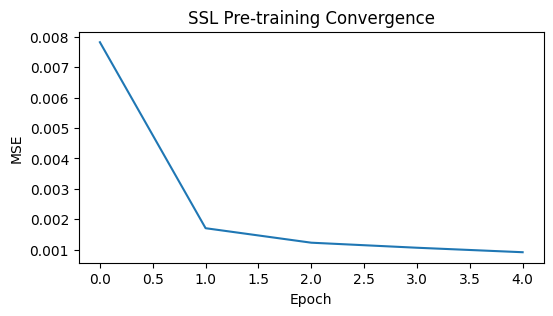

In [ ]:
# BLOCK 6: Phase 1 - SSL Pre-training
print("\n=== PHASE 1: SSL PRE-TRAINING ===")

# 1. Setup Dataset
# Use 80% of data for SSL (or 100% ideally, but splitting for validation here)
X_train, X_val, _, _ = train_test_split(X, Y_cls, test_size=0.2, random_state=42)

ssl_train_ds = IMUDataset(X_train, None, None, mode='ssl')
ssl_train_loader = DataLoader(ssl_train_ds, batch_size=BATCH_SIZE, shuffle=True)

# 2. Initialize Model
model = IMUTransformer(d_model=D_MODEL, num_classes=NUM_CLASSES, pred_len=PRED_LEN).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion_mse = nn.MSELoss()

# 3. Train Loop
ssl_epochs = 5 # Increase this for real results
ssl_losses = []

for epoch in range(ssl_epochs):
    print(f"\nEpoch {epoch+1}/{ssl_epochs}")
    loss = train_epoch(model, ssl_train_loader, optimizer, criterion_mse, 'ssl', device)
    ssl_losses.append(loss)
    print(f"\n    --> Avg SSL Loss: {loss:.4f}")

# Save the pretrained encoder weights
torch.save(model.state_dict(), "ssl_pretrained_weights.pth")
print("--> DEBUG: Pre-trained model saved.")

# Plot SSL Loss
plt.figure(figsize=(6,3))
plt.plot(ssl_losses, label='Reconstruction Loss')
plt.title('SSL Pre-training Convergence')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()


=== PHASE 2: HAR LABEL EFFICIENCY ===

--> Testing Fraction: 1.0%
    Training SSL-initialized model...
    --> Mode: har | Batch 40 | Loss: 0.8582    --> SSL Acc: 0.6588
    Training Scratch model...
    --> Mode: har | Batch 40 | Loss: 0.8215    --> Scratch Acc: 0.6361

--> Testing Fraction: 10.0%
    Training SSL-initialized model...
    --> Mode: har | Batch 470 | Loss: 0.5030    --> SSL Acc: 0.7754
    Training Scratch model...
    --> Mode: har | Batch 470 | Loss: 0.7160    --> Scratch Acc: 0.7226

--> Testing Fraction: 50.0%
    Training SSL-initialized model...
    --> Mode: har | Batch 2350 | Loss: 0.3285    --> SSL Acc: 0.8202
    Training Scratch model...
    --> Mode: har | Batch 2350 | Loss: 0.6211    --> Scratch Acc: 0.8040

--> Testing Fraction: 100.0%
    Training SSL-initialized model...
    --> Mode: har | Batch 4700 | Loss: 0.2179    --> SSL Acc: 0.8404
    Training Scratch model...
    --> Mode: har | Batch 4700 | Loss: 0.5543    --> Scratch Acc: 0.8260


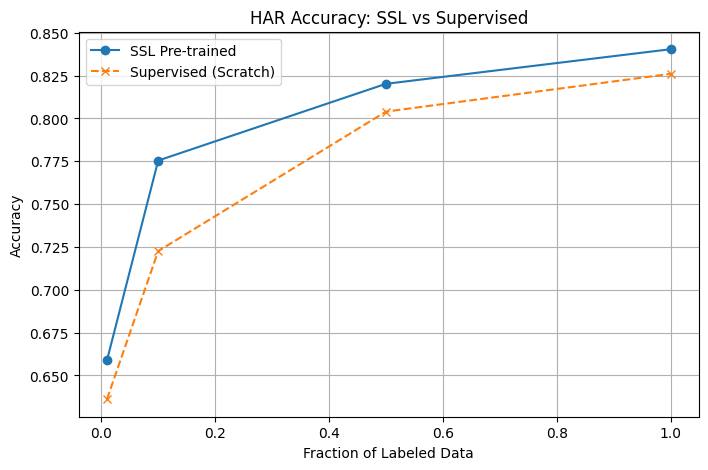

In [ ]:
# BLOCK 7: Downstream HAR - Label Efficiency
print("\n=== PHASE 2: HAR LABEL EFFICIENCY ===")

fractions = [0.01, 0.1, 0.5, 1.0] # 1%, 10%, 50%, 100% labels
acc_ssl = []
acc_scratch = []

# Split Data for HAR
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_cls, test_size=0.2, random_state=42)
test_ds = IMUDataset(X_test, None, Y_test, mode='har')
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
criterion_ce = nn.CrossEntropyLoss()

def evaluate_acc(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(device), tgt.to(device)
            out = model(inp, mode='har')
            _, predicted = torch.max(out.data, 1)
            total += tgt.size(0)
            correct += (predicted == tgt).sum().item()
    return correct / total

for frac in fractions:
    print(f"\n--> Testing Fraction: {frac*100}%")

    # Subsample Training Data
    subset_size = int(len(X_train) * frac)
    indices = np.random.choice(len(X_train), subset_size, replace=False)
    X_sub = X_train[indices]
    Y_sub = Y_train[indices]

    train_ds = IMUDataset(X_sub, None, Y_sub, mode='har')
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # --- Run 1: With SSL Weights ---
    model_ssl = IMUTransformer(d_model=D_MODEL, num_classes=NUM_CLASSES).to(device)
    model_ssl.load_state_dict(torch.load("ssl_pretrained_weights.pth"), strict=False)

    # Freeze Encoder? (Optional: typically we fine-tune all, but with low LR)
    opt_ssl = optim.Adam(model_ssl.parameters(), lr=1e-4)

    # Fine-tune
    print("    Training SSL-initialized model...")
    for ep in range(3): # Short training for demo
        train_epoch(model_ssl, train_loader, opt_ssl, criterion_ce, 'har', device)

    acc = evaluate_acc(model_ssl, test_loader)
    acc_ssl.append(acc)
    print(f"    --> SSL Acc: {acc:.4f}")

    # --- Run 2: From Scratch ---
    model_scr = IMUTransformer(d_model=D_MODEL, num_classes=NUM_CLASSES).to(device)
    opt_scr = optim.Adam(model_scr.parameters(), lr=1e-4)

    print("    Training Scratch model...")
    for ep in range(3):
        train_epoch(model_scr, train_loader, opt_scr, criterion_ce, 'har', device)

    acc = evaluate_acc(model_scr, test_loader)
    acc_scratch.append(acc)
    print(f"    --> Scratch Acc: {acc:.4f}")

# Plot Results
plt.figure(figsize=(8,5))
plt.plot(fractions, acc_ssl, marker='o', label='SSL Pre-trained')
plt.plot(fractions, acc_scratch, marker='x', linestyle='--', label='Supervised (Scratch)')
plt.xlabel('Fraction of Labeled Data')
plt.ylabel('Accuracy')
plt.title('HAR Accuracy: SSL vs Supervised')
plt.legend()
plt.grid(True)
plt.show()


=== PHASE 3: FORECASTING HORIZON ANALYSIS ===
Training Forecast Models...
    --> Mode: forecast | Batch 4700 | Loss: 0.0128

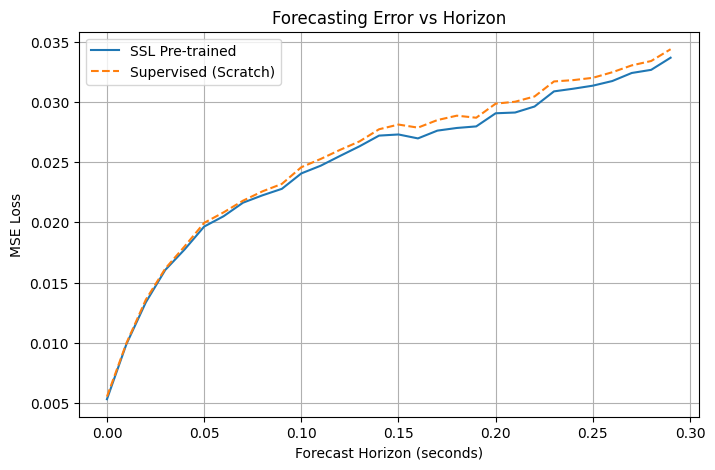

In [ ]:
# BLOCK 8: Forecasting Horizon Analysis
print("\n=== PHASE 3: FORECASTING HORIZON ANALYSIS ===")

# We compare the SSL-based model vs a simple baseline (e.g., repeat last value or scratch model)
# Here we compare SSL-finetuned vs Scratch

X_train, X_test, Y_fore_train, Y_fore_test = train_test_split(X, Y_fore, test_size=0.2, random_state=42)

# Datasets
train_ds = IMUDataset(X_train, Y_fore_train, None, mode='forecast')
test_ds = IMUDataset(X_test, Y_fore_test, None, mode='forecast')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# 1. Train Forecasting Models
model_ssl_fore = IMUTransformer(d_model=D_MODEL, num_classes=NUM_CLASSES, pred_len=PRED_LEN).to(device)
model_ssl_fore.load_state_dict(torch.load("ssl_pretrained_weights.pth"), strict=False)
opt_ssl = optim.Adam(model_ssl_fore.parameters(), lr=1e-4)

model_scr_fore = IMUTransformer(d_model=D_MODEL, num_classes=NUM_CLASSES, pred_len=PRED_LEN).to(device)
opt_scr = optim.Adam(model_scr_fore.parameters(), lr=1e-4)

print("Training Forecast Models...")
for ep in range(5):
    train_epoch(model_ssl_fore, train_loader, opt_ssl, criterion_mse, 'forecast', device)
    train_epoch(model_scr_fore, train_loader, opt_scr, criterion_mse, 'forecast', device)

# 2. Evaluate per time-step
def get_error_per_step(model, loader):
    model.eval()
    errors = np.zeros(PRED_LEN)
    counts = 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(device), tgt.to(device)
            out = model(inp, mode='forecast') # [batch, pred_len, 3]

            # MSE per time step (averaged over x,y,z and batch)
            diff = (out - tgt) ** 2
            mse_step = torch.mean(diff, dim=2) # [batch, pred_len]
            errors += torch.sum(mse_step, dim=0).cpu().numpy()
            counts += inp.size(0)
    return errors / counts

ssl_errors = get_error_per_step(model_ssl_fore, test_loader)
scr_errors = get_error_per_step(model_scr_fore, test_loader)

# Time axis for plotting
time_axis = np.arange(PRED_LEN) / FREQ

plt.figure(figsize=(8,5))
plt.plot(time_axis, ssl_errors, label='SSL Pre-trained')
plt.plot(time_axis, scr_errors, linestyle='--', label='Supervised (Scratch)')
plt.xlabel('Forecast Horizon (seconds)')
plt.ylabel('MSE Loss')
plt.title('Forecasting Error vs Horizon')
plt.legend()
plt.grid(True)
plt.show()